 # **Mini trabalho de DAA**


# Ano Letivo 25/26


# Trabalho realizado por:
* José Romeiro, nº 129838
* Gustavo Gordão, nº 676767
* Miguel Antão, nº 129827

# **Análise de Redes Funcionais**
No decorrer deste trabalho, foi desenvolvida, conforme proposto, uma API para análise estrutural e estatística de redes de interações entre personagens de universos ficcionais, mais específicamente da saga de *Game Of Thrones* e da saga da *Marvel*.

A análise das redes permite extrair métricas cruciais sobre a topologia do grafo, desde a sua conectividade até à identificação dos vértices mais influentes através das métricas de centralidade.

Ao longo deste relatório, exploraremos a implementação destes algoritmos construidos de raiz, a extração de conclusões sobre o papel narrativo das personagens nestes universos, e realizaremos a análise empírica da escalabilidade e complexidade temporal de cada método.


## 1. Bibliotecas Usadas

Como o enunciado proíbe expressamente a utilização de módulos Python específicos para representação de grafos ou cálculo de métricas (como o `networkx` ou `igraph`), a implementação foi feita de raiz utilizando apenas estruturas de dados nativas e algumas bibliotecas de suporte do Python:

* **csv** - Utilizada para a leitura e processamento inicial dos datasets fornecidos (`got_book1.csv`, `got_full.csv`, etc.), permitindo extrair a origem, destino e peso das co-ocorrências.
* **collections (deque)** - Essencial para aceder a uma estrutura de fila duplamente terminada (*double-ended queue*). Esta estrutura permite inserções e remoções eficientes nas extremidades, sendo o motor base para garantir a complexidade ideal no algoritmo de Travessia em Largura (BFS) e no algoritmo de Brandes.
* **math** - Para a realização de cálculos matemáticos específicos, como o cálculo da raiz quadrada durante a normalização da *Eigenvector Centrality*.
* **time** - Utilizada para a medição empírica dos tempos de execução dos algoritmos de centralidade, necessária para a análise de escalabilidade na reta final do trabalho.
* **matplotlib.pyplot** - Fundamental para a visualização gráfica dos resultados solicitados, permitindo a construção do histograma da distribuição de graus, e dos gráficos de análise temporal (gráfico log-log, gráfico de barras e gráfico de dispersão).

In [2]:
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import csv                 
from collections import deque 
import math               
import time
import matplotlib.pyplot as plt 
import sys
import pandas as pd
import statistics

# 1.1. Contrutores

# 1.1.1. Classe Graph

In [4]:
class Graph:

    def __init__(self):
        self._adjancencies = {}
        self._vertices = {}      
        self._n = 0              
        self._m = 0              
        
    def __str__(self):
        if self._n == 0:
            ret = "DAA-Graph: <empty>\n"
        else:
            ret = "DAA-Graph:\n"
            for vertex in self._adjancencies.keys():
                
                ret += str(vertex) + ": "
                for edge in self.incident_edges(vertex.vertex_id()):
                    ret += str(edge) + "; "
                ret += "\n"
        return ret
    
    def is_directed(self): 
        return False
    
    def order(self):
        return self._n
    
    def size(self):
        return self._m 
    
    def has_vertex(self, vertex_id):
        return vertex_id in self._vertices
    
    def has_edge(self, u_id, v_id):
        if not self.has_vertex(u_id) or not self.has_vertex(v_id):
            return False
        else:
            vertex_u = self._vertices[u_id]
            vertex_v = self._vertices[v_id]
            return vertex_v in self._adjancencies[vertex_u]
        
    def insert_vertex(self, vertex_id):
        if not self.has_vertex(vertex_id):
            vertex = Vertex(vertex_id)          
            self._vertices[vertex_id] = vertex  
            self._adjancencies[vertex] = {}     
            self._n +=1                       

    def insert_edge(self, u_id, v_id, weight=0):
        if not self.has_vertex(u_id):
            self.insert_vertex(u_id) 
        if not self.has_vertex(v_id):
            self.insert_vertex(v_id)       
        if not self.has_edge(u_id, v_id):
            self._m +=1         
        else:
           pass                 
        vertex_u = self._vertices[u_id]
        vertex_v = self._vertices[v_id]  
        e = Edge(vertex_u, vertex_v, weight)    
        self._adjancencies[vertex_u][vertex_v] = e 
        self._adjancencies[vertex_v][vertex_u] = e 
    def degree(self, vertex_id):
        return len(self._adjancencies[self._vertices[vertex_id]])
    
    def get_vertex(self, vertex_id):
        return None if not self.has_vertex(vertex_id) else self._vertices[vertex_id] 
    
    def get_edge(self, u_id, v_id): 
        if not self.has_edge(u_id, v_id):
            return None
        else:
            vertex_u = self._vertices[u_id]
            vertex_v = self._vertices[v_id]
            return self._adjancencies[vertex_u][vertex_v]
    
    def vertices(self):
        return self._vertices.values()

    def edges(self):
        seen = {} 
        for adj_map in self._adjancencies.values():
            for edge in adj_map.values():
                if edge not in seen:
                    yield edge
                seen[edge] = True

    def incident_edges(self, vertex_id):
        vertex = self._vertices[vertex_id]
        for edge in self._adjancencies[vertex].values():
            yield edge

    def has_neighbors(self, vertex_id):
        if not self.has_vertex(vertex_id):
            return False
        return self.degree(vertex_id) == 0
    
    def remove_vertex(self, vertex_id):
        if self.has_vertex(vertex_id):
            lst_copied = list(self.incident_edges(vertex_id)) 
            for edge in lst_copied:
                x, y = edge.endpoints()
                self.remove_edge(x.vertex_id(),y.vertex_id()) 
            del self._adjancencies[self._vertices[vertex_id]]  
            del self._vertices[vertex_id]                      
            self._n -=1                                      
        
    def remove_edge(self, u_id, v_id):
        if  self.has_edge(u_id, v_id):
            vertex_u = self._vertices[u_id]
            vertex_v = self._vertices[v_id]
            del self._adjancencies[vertex_u][vertex_v]
            if vertex_u != vertex_v: 
                del self._adjancencies[vertex_v][vertex_u]
            self._m -=1

# 1.1.2. Classe Edge

In [5]:
class Edge:
    def __init__(self, vertex_1, vertex_2, weight):
        self._vertex_1 = vertex_1
        self._vertex_2 = vertex_2
        self._weight = weight

    def __hash__(self):
        return hash( (self._vertex_1, self._vertex_2) )

    def __str__(self):
        return'e({0},{1})w={2}'.format(self._vertex_1, self._vertex_2, self._weight)

    def __eq__(self, other):
        return self._vertex_1 == other._vertex_1 and self._vertex_2 == other._vertex_2

    def endpoints(self):
        return (self._vertex_1, self._vertex_2)

    def cost(self):
        return self._weight
    
    def opposite(self, vertex):
        if vertex == self._vertex_1:
            return self._vertex_2
        elif vertex == self._vertex_2:
            return self._vertex_1
        else:
            return None

# 1.1.3. Classe Vertex

In [6]:
class Vertex:    
    def __init__(self, vertex_id):
        self._vertex_id = vertex_id 
        
    def __hash__(self):
        return hash(self._vertex_id) 

    def __str__(self):
        return'v{0}'.format(self._vertex_id)

    def __eq__(self, vertex):
        return self._vertex_id == vertex._vertex_id

    def __lt__(self, vertex):
        return self._vertex_id < vertex._vertex_id
    
    def __le__(self, vertex):
        return self._vertex_id <= vertex._vertex_id
    
    def __gt__(self, vertex):
        return self._vertex_id > vertex._vertex_id
    
    def __ge__(self, vertex):
        return self._vertex_id >= vertex._vertex_id
    
    def vertex_id(self):
        ''' Devolve o elemento guardado neste vértice.'''
        return self._vertex_id

# 1.1.4. API CentralityAnalyzer

In [7]:
import pandas as pd
import math
from collections import deque

# --- Mantemos a tua função de carregamento igual ---
def load_graph_from_file(filename):
    graph = Graph()
    data = pd.read_csv(filename)
    for index, row in data.iterrows():
        source = str(row.iloc[0])
        target = str(row.iloc[1])
        if "marvel" in filename.lower():
            weight = float(row.iloc[2])
        else:
            weight = float(row.iloc[3])
        graph.insert_edge(source, target, weight)
    return graph

g1 = load_graph_from_file("got_book1.csv")
g2 = load_graph_from_file("got_full.csv")
g3 = load_graph_from_file("marvel_small.csv")
g4 = load_graph_from_file("marvel_full.csv")

class CentralityAnalyzer:
    def __init__(self, graph_data):
        self.graph_original = graph_data  # Guardamos para métodos que pedem .order()
        self.n = graph_data.order()
        self.adj = {} # Usaremos 'self.adj' consistentemente
        
        # Corrigido: Extrair vértices e arestas do objeto Graph original
        for v in graph_data.vertices():
            v_id = v.vertex_id()
            if v_id not in self.adj:
                self.adj[v_id] = {}
        
        for e in graph_data.edges():
            u, v = e.endpoints()
            u_id, v_id = u.vertex_id(), v.vertex_id()
            weight = e.cost()
            self.adj[u_id][v_id] = weight
            self.adj[v_id][u_id] = weight
        
        self.num_vertices = len(self.adj)
        self._dist_to = {} # Para o path_to funcionar
        self._edge_to = {}

    def bfs(self, source):
        # Reset de estados para cada BFS
        self._dist_to = {v: float('inf') for v in self.adj}
        self._edge_to = {v: None for v in self.adj}
        
        self._dist_to[source] = 0
        queue = deque([source])
        
        while queue:
            u = queue.popleft()
            for v in self.adj[u]:
                if self._dist_to[v] == float('inf'):
                    self._dist_to[v] = self._dist_to[u] + 1
                    self._edge_to[v] = u
                    queue.append(v)
        return self._dist_to

    # Novo: Adicionado para o teu teste de "caminho" funcionar
    def path_to(self, v):
        if v not in self._dist_to or self._dist_to[v] == float('inf'):
            return ["Caminho não encontrado"]
        path = []
        curr = v
        while curr is not None:
            path.append(curr)
            curr = self._edge_to[curr]
        return path[::-1]

    def num_components(self):
        visited = set()
        count = 0
        for vertice in self.adj:
            if vertice not in visited:
                count += 1
                comp_distances = self.bfs(vertice)
                for v, dist in comp_distances.items():
                    if dist != float('inf'):
                        visited.add(v)
        return count

    def largest_component(self):
        visited = set()
        largest_nodes = []
        for vertice in self.adj:
            if vertice not in visited:
                component = []
                comp_distances = self.bfs(vertice)
                for v, dist in comp_distances.items():
                    if dist != float('inf'):
                        visited.add(v)
                        component.append(v)
                if len(component) > len(largest_nodes):
                    largest_nodes = component
        
        # Para o teste .order() funcionar, retornamos um objeto que simule o Grafo
        class SubGraph:
            def __init__(self, n): self.n = n
            def order(self): return self.n
            
        return SubGraph(len(largest_nodes))
    
    def diameter(self):
        # 1. Obter os nós da maior componente
        nodes = self.largest_component() 
        # Se largest_component retornar um objeto SubGraph (da minha correção anterior)
        # precisamos de uma lista de nós. Vamos adaptar:
        if hasattr(nodes, 'n'): # Se for o objeto dummy
            # Precisamos de encontrar os nós reais novamente ou mudar o largest_component
            # Para facilitar, vamos assumir que queres os nós:
            visited = set()
            largest_nodes = []
            for vertice in self.adj:
                if vertice not in visited:
                    component = []
                    comp_distances = self.bfs(vertice)
                    for v, dist in comp_distances.items():
                        if dist != float('inf'):
                            visited.add(v)
                            component.append(v)
                    if len(component) > len(largest_nodes):
                        largest_nodes = component
            nodes = largest_nodes

        max_dist = 0
        start_node = None
        end_node = None

        for u in nodes:
            distances = self.bfs(u)
            for v in nodes:
                if distances[v] != float('inf') and distances[v] > max_dist:
                    max_dist = distances[v]
                    start_node = u
                    end_node = v
        
        # Reconstruir o caminho para o teste
        self.bfs(start_node)
        path = []
        curr = end_node
        while curr is not None:
            path.append(curr)
            curr = self._edge_to.get(curr)
            
        return max_dist, (start_node, end_node), path[::-1]

    def degree_distribution(self):
        dist = {}
        for v in self.adj:
            degree = len(self.adj[v])
            dist[degree] = dist.get(degree, 0) + 1
        return dist

    def degree_centrality(self):
        dc_scores = {}
        n = self.num_vertices
        if n <= 1: return {v: 0 for v in self.adj}
        for v in self.adj:
            dc_scores[v] = len(self.adj[v]) / (n - 1)
        return dc_scores

    def closeness_centrality(self):
        cc_scores = {}
        n = self.num_vertices
        for u in self.adj:
            distances = self.bfs(u)
            reachable_nodes = [d for d in distances.values() if d > 0 and d != float('inf')]
            num_reachable = len(reachable_nodes)
            sum_dist = sum(reachable_nodes)
            
            if sum_dist > 0:
                # Wasserman & Faust formula
                cc_scores[u] = (num_reachable / (n - 1)) * (num_reachable / sum_dist)
            else:
                cc_scores[u] = 0.0
        return cc_scores

    def eigenvector_centrality(self, max_iter=100, tol=1e-6):
        n = self.num_vertices
        scores = {v: 1.0 / n for v in self.adj}
        for k in range(max_iter):
            new_scores = {v: 0.0 for v in self.adj}
            for u in self.adj:
                for v in self.adj[u]:
                    new_scores[u] += scores[v]
            
            norm = math.sqrt(sum(s**2 for s in new_scores.values()))
            if norm == 0: norm = 1.0
            for v in new_scores: new_scores[v] /= norm
            
            diff = sum(abs(new_scores[v] - scores[v]) for v in self.adj)
            scores = new_scores
            if diff < tol: return scores, k + 1
        return scores, max_iter

    def betweenness_centrality(self):
        cb = {v: 0.0 for v in self.adj}
        for s in self.adj:
            S, P, sigma, d = [], {w: [] for w in self.adj}, {w: 0 for w in self.adj}, {w: -1 for w in self.adj}
            sigma[s], d[s] = 1, 0
            Q = deque([s])
            while Q:
                v = Q.popleft()
                S.append(v)
                for w in self.adj[v]:
                    if d[w] < 0:
                        Q.append(w)
                        d[w] = d[v] + 1
                    if d[w] == d[v] + 1:
                        sigma[w] += sigma[v]
                        P[w].append(v)
            delta = {v: 0.0 for v in self.adj}
            while S:
                w = S.pop()
                for v in P[w]:
                    delta[v] += (sigma[v] / sigma[w]) * (1 + delta[w])
                if w != s: cb[w] += delta[w]
        for v in cb: cb[v] /= 2.0
        return cb

# 2. Análise Estrutural dos Grafos

## 2.1. BFS (Breadth-First Search)

O algoritmo de **Travessia em Largura (BFS)** é uma técnica fundamental para explorar a estrutura de um grafo. A sua principal função é visitar todos os vértices alcançáveis a partir de uma fonte específica, garantindo que a exploração ocorre por níveis de distância (camadas).

**Funcionamento e Estruturas Auxiliares:**
*   **Fila (Queue)**: É a estrutura de dados central do algoritmo, funcionando sob o princípio FIFO (*First-In, First-Out*). Ela garante que os vértices descobertos primeiro sejam os primeiros a ser explorados, mantendo a ordem de níveis.
*   **Dicionário de Distâncias/Visitados**: Utilizado para armazenar a distância mínima da fonte a cada nó e evitar ciclos ou processamento redundante de vértices já visitados.

Em grafos não pesados (ou com pesos unitários), a BFS é o método mais eficiente para encontrar o caminho mais curto entre dois nós.

#### **Análise de Complexidade Temporal**

A complexidade temporal da BFS é de **$\mathcal{O}(n + m)$**, onde $n$ representa o número de vértices e $m$ o número de arestas do grafo.

**Justificação:**
*   **Vértices ($\mathcal{O}(n)$)**: Cada vértice alcançável é inserido e removido da fila exatamente uma vez.
*   **Arestas ($\mathcal{O}(m)$)**: Quando um vértice é removido da fila, o algoritmo percorre a sua lista de adjacências para descobrir novos vizinhos. Num grafo não orientado, cada aresta é verificada exatamente duas vezes (uma por cada extremidade).
*   **Operações de Fila**: As operações de `enqueue` e `dequeue` são realizadas em tempo constante, $\mathcal{O}(1)$.

Somando estas contribuições, obtemos uma complexidade linear em relação ao tamanho da representação do grafo.

## 2.2. Conectividade

A conectividade é uma propriedade estrutural que define se existe pelo menos um caminho entre qualquer par de vértices na rede. Numa rede de interações ficcionais, esta métrica permite identificar se a narrativa ocorre num universo integrado ou se existem núcleos de personagens isolados.

Nesta secção, implementamos os seguintes métodos:
*   **`num_components()`**: Devolve o número total de componentes conexas do grafo.
*   **`largest_component()`**: Identifica e extrai o subgrafo correspondente à maior componente conexa (ordem do grafo).

O algoritmo utilizado para estas operações baseia-se na **Travessia em Largura (BFS)**. Ao iniciar uma BFS num vértice, todos os nós alcançáveis são marcados como pertencentes à mesma componente. O processo é repetido para vértices não visitados até que todo o grafo seja explorado.



#### **Análise de Complexidade Temporal**

A complexidade temporal dos métodos de conectividade é **$\mathcal{O}(n + m)$**, onde $n$ é o número de vértices e $m$ o número de arestas.

**Justificação:**
*   O algoritmo itera sobre o conjunto de $n$ vértices para garantir que todos são processados.
*   Cada vértice é visitado uma única vez através da BFS.
*   Cada aresta é explorada exatamente duas vezes (uma por cada extremidade, dado o grafo ser não orientado), resultando num custo proporcional a $m$.
*   A soma de todas as operações de exploração de vizinhos em todas as componentes conexas é limitada por $\mathcal{O}(n + m)$.

In [8]:
analyzer1 = CentralityAnalyzer(g1) #got_book1.csv
analyzer2 = CentralityAnalyzer(g2) #got_full.csv

comps1 = analyzer1.num_components()
comps2 = analyzer2.num_components()

largestComp1 = analyzer1.largest_component()
largestComp2 = analyzer2.largest_component()

print(f"got_book1.csv:")
print(f"Número de Componentes = {comps1}. " + ("O grafo é conexo tendo apenas uma componente conexa." if comps2 == 1 else "O grafo é desconexo"))
print(f"Maior Componente = {largestComp1.order()}")

print(f"\ngot_full.csv:")
print(f"Número de Componentes = {comps2}. " + ("O grafo é conexo tendo apenas uma componente conexa." if comps2 == 1 else "O grafo é desconexo"))
print(f"Maior Componente = {largestComp2.order()}")
print()
print("Se existissem outras componentes conexas mais pequenas, apesar de não estarem ligados à história principal da Saga, os seus vértices poderiam representar um figurante, alguma personagem de ambientação para dar profundidade ao mundo ou até mesmo uma história isolada. ")

#Ligação de duas personagens no got_book1.csv
analyzer1.bfs("Bran-Stark")
caminho1 = analyzer1.path_to("Daenerys-Targaryen")
print(f"\nCaminho(got_book1.csv): {' -> '.join(caminho1)}")

#Ligação de duas personagens no got_full.csv
analyzer2.bfs("Bran-Stark")
caminho2 = analyzer2.path_to("Daenerys-Targaryen")
print(f"Caminho(got_full.csv): {' -> '.join(caminho2)}")

got_book1.csv:
Número de Componentes = 1. O grafo é conexo tendo apenas uma componente conexa.
Maior Componente = 187

got_full.csv:
Número de Componentes = 1. O grafo é conexo tendo apenas uma componente conexa.
Maior Componente = 796

Se existissem outras componentes conexas mais pequenas, apesar de não estarem ligados à história principal da Saga, os seus vértices poderiam representar um figurante, alguma personagem de ambientação para dar profundidade ao mundo ou até mesmo uma história isolada. 

Caminho(got_book1.csv): Bran-Stark -> Eddard-Stark -> Daenerys-Targaryen
Caminho(got_full.csv): Bran-Stark -> Cersei-Lannister -> Daenerys-Targaryen


## 2.3. Distribuição de graus e top-10

Nesta secção, exploramos a estrutura de ligações do grafo através da análise dos **graus dos vértices**. O grau de um vértice representa o número de incidentes nele — no contexto das redes sociais (como Marvel ou GoT), isto traduz-se no número de interações diretas que uma personagem possui.

A **Distribuição de Graus** é uma métrica estatística que nos permite entender a topologia da rede. Em vez de olharmos para personagens individuais, analisamos a frequência com que cada valor de grau ocorre em todo o grafo.

* **O que revela:** Permite identificar se a rede é "escala-livre" (onde poucos nós têm muitíssimas ligações e a maioria tem poucas) ou se é uma rede mais uniforme.
* **Utilidade:** Ajuda a detetar a presença de *hubs* (personagens centrais que conectam diferentes núcleos da história).

Enquanto a distribuição nos dá uma visão global, o **Top-10** identifica os protagonistas estruturais da rede. Esta métrica lista as 10 personagens com o maior número de ligações diretas.

1.  **Centralidade Imediata:** Indica quem são as personagens com maior visibilidade e alcance direto no universo analisado.
2.  **Robustez da Rede:** Em redes complexas, estas 10 personagens funcionam frequentemente como "pontes". Se forem removidas, a rede pode fragmentar-se rapidamente em componentes isoladas.
3.  **Comparação entre Obras:** Permite observar, por exemplo, como o protagonismo de uma personagem evolui de um livro individual para a saga completa (*got_book1.csv* vs *got_full.csv*).

Geralmente, estes dados são apresentados através de uma tabela de frequências e um gráfico de barras:

| Personagem | Grau (Nº de Ligações) |
| :--- | :---: |
| Personagem A | 150 |
| Personagem B | 142 |
| ... | ... |

> **Nota Teórica:** Em grafos não-orientados, o grau é simplesmente a contagem de vizinhos. No nosso analisador, utilizamos esta métrica para alimentar o cálculo da **Degree Centrality**, normalizando o grau pelo número total de nós possíveis ($n-1$).

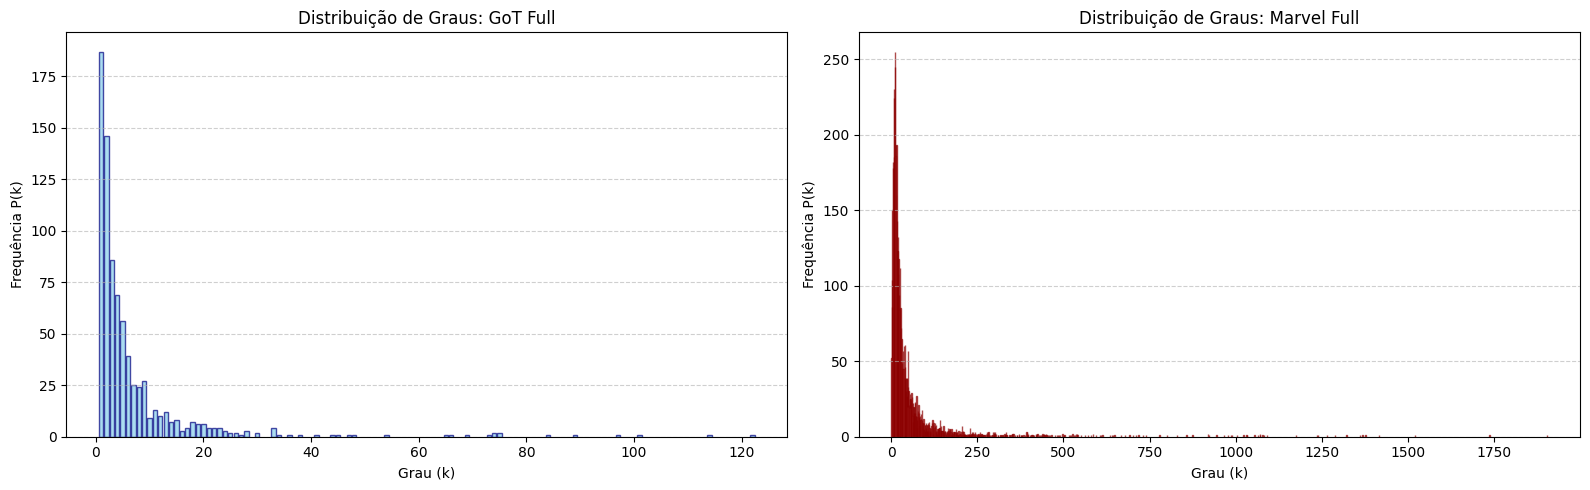

--- Top 10: got_book1.csv ---
Personagem                | Grau 
-----------------------------------
Eddard-Stark              | 66   
Robert-Baratheon          | 50   
Tyrion-Lannister          | 46   
Catelyn-Stark             | 43   
Jon-Snow                  | 37   
Robb-Stark                | 35   
Sansa-Stark               | 35   
Bran-Stark                | 32   
Cersei-Lannister          | 30   
Joffrey-Baratheon         | 30   


--- Top 10: got_full.csv ---
Personagem                | Grau 
-----------------------------------
Tyrion-Lannister          | 122  
Jon-Snow                  | 114  
Jaime-Lannister           | 101  
Cersei-Lannister          | 97   
Stannis-Baratheon         | 89   
Arya-Stark                | 84   
Catelyn-Stark             | 75   
Sansa-Stark               | 75   
Robb-Stark                | 74   
Eddard-Stark              | 74   


--- Top 10: marvel_full.csv ---
Personagem                | Grau 
-----------------------------------
CAPTAIN AMERICA

In [9]:
# 1. Inicializar os analisadores
analyzer_got = CentralityAnalyzer(g2)    # got_full.csv
analyzer_marvel = CentralityAnalyzer(g4) # marvel_full.csv
analyzer_b1 = CentralityAnalyzer(g1)     # got_book1.csv

# 2. Função auxiliar para extrair Top 10 e Dados de Distribuição
def get_stats(analyzer):
    # Distribuição
    dist = analyzer.degree_distribution()
    x = list(dist.keys())
    y = list(dist.values())
    
    # Top 10 (Usando a adjacência interna do analyzer)
    # Se o teu analyzer usa self.adj, extraímos de lá:
    degree_list = [(name, len(neighbors)) for name, neighbors in analyzer.adj.items()]
    top_10 = sorted(degree_list, key=lambda x: x[1], reverse=True)[:10]
    
    return x, y, top_10

# Obter dados
x_got, y_got, top_got = get_stats(analyzer_got)
x_marv, y_marv, top_marv = get_stats(analyzer_marvel)
x_b1, y_b1, top_b1 = get_stats(analyzer_b1)

# --- VISUALIZAÇÃO DOS GRÁFICOS ---
# Vamos colocar os dois principais (GoT Full vs Marvel Full) lado a lado para comparar
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Gráfico GoT Full
ax1.bar(x_got, y_got, color='skyblue', edgecolor='navy', alpha=0.7)
ax1.set_title("Distribuição de Graus: GoT Full")
ax1.set_xlabel("Grau (k)")
ax1.set_ylabel("Frequência P(k)")
ax1.grid(axis='y', linestyle='--', alpha=0.6)

# Gráfico Marvel Full
ax2.bar(x_marv, y_marv, color='indianred', edgecolor='darkred', alpha=0.7)
ax2.set_title("Distribuição de Graus: Marvel Full")
ax2.set_xlabel("Grau (k)")
ax2.set_ylabel("Frequência P(k)")
ax2.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

# --- PRINT DOS RESULTADOS (TOP 10) ---
def print_top(lista, nome_ficheiro):
    print(f"--- Top 10: {nome_ficheiro} ---")
    print(f"{'Personagem':<25} | {'Grau':<5}")
    print("-" * 35)
    for nome, grau in lista:
        print(f"{nome:<25} | {grau:<5}")
    print("\n")

print_top(top_b1, "got_book1.csv")
print_top(top_got, "got_full.csv")
print_top(top_marv, "marvel_full.csv")

# 2.4. Diâmetro da Rede

O **Diâmetro** de um grafo é definido como a maior distância de todos os caminhos mais curtos (*shortest paths*) entre qualquer par de nós na rede. Em termos simples, representa o "pior cenário" para a propagação de informação: o número máximo de passos que alguém teria de dar para ir de uma ponta à outra do grafo.

Para calcular o diâmetro, é necessário que o grafo seja **conexo** (todos os nós estarem ligados). Caso o grafo possua várias componentes isoladas, o diâmetro é calculado sobre a **Maior Componente Conexa (LCC)**. 

* **Eficiência de Rede:** Um diâmetro pequeno indica uma rede "compacta", onde a informação (ou um boato) se espalha muito rapidamente.
* **Fenómeno do Mundo Pequeno:** Muitas redes sociais reais, apesar de terem milhares de nós, apresentam diâmetros surpreendentemente pequenos (como os famosos "seis graus de separação").
* **Comparação de Universos:** Comparar o diâmetro do Livro 1 com o da Saga completa de GoT permite perceber se o universo se tornou mais denso ou mais disperso à medida que novas personagens foram introduzidas.

> **Nota Técnica:** O cálculo envolve executar uma **BFS (Breadth-First Search)** a partir de cada nó para encontrar as distâncias máximas, resultando numa complexidade de $O(V \cdot (V + E))$.

Ficheiro             | Diâmetro   | Extremidades
--------------------------------------------------
GoT Livro 1          | 7          | Clement-Piper j<-> Fogo
   Exemplo de caminho crítico: Clement-Piper -> Karyl-Vance -> Edmure-Tully ... Drogo -> Ogo -> Fogo
------------------------------
GoT Full             | 9          | Lucifer-Long j<-> Gormon-Tyrell
   Exemplo de caminho crítico: Lucifer-Long -> Caggo -> Quentyn-Martell ... Pate-(novice) -> Walgrave -> Gormon-Tyrell
------------------------------
Marvel Small         | 3          | Loki [asgardian] j<-> Skin / Angelo Espinosa
   Exemplo de caminho crítico: Loki [asgardian] -> Black Panther / T'chal -> Wolverine / Logan ... Black Panther / T'chal -> Wolverine / Logan -> Skin / Angelo Espinosa
------------------------------
Marvel Full          | 5          | 24-HOUR MAN/EMMANUEL j<-> 8-BALL/
   Exemplo de caminho crítico: 24-HOUR MAN/EMMANUEL -> FROST, CARMILLA -> ABRAXAS ... HUMAN TORCH/JOHNNY S -> SLEEPWALKER -> 8-BALL/
------

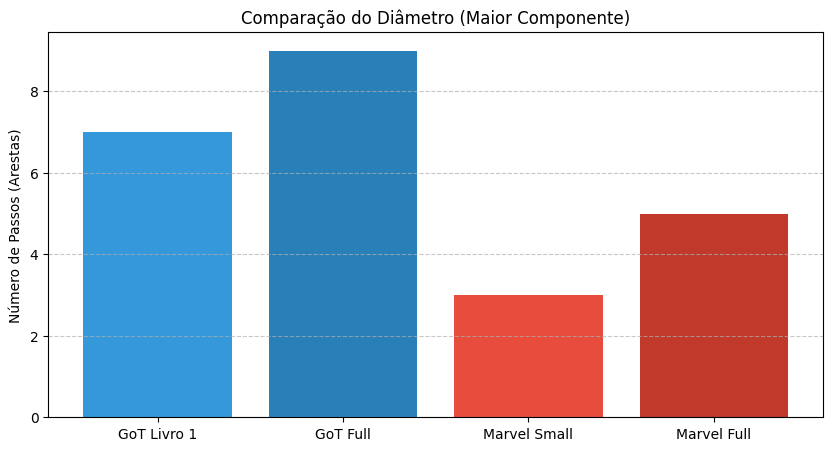

In [10]:
def test_diameter_analysis(analyzers_dict):
    print("="*50)
    print(f"{'Ficheiro':<20} | {'Diâmetro':<10} | {'Extremidades'}")
    print("-"*50)

    for label, analyzer in analyzers_dict.items():
        # O método diameter() da tua classe deve devolver (max_dist, (start, end), path)
        try:
            diam, nodes, path = analyzer.diameter()
            
            p1, p2 = nodes if nodes else ("N/A", "N/A")
            
            print(f"{label:<20} | {diam:<10} | {p1} j<-> {p2}")
            
            if path:
                print(f"   Exemplo de caminho crítico: {' -> '.join(path[:3])} ... {' -> '.join(path[-3:])}")
                print("-" * 30)
                
        except Exception as e:
            print(f"{label:<20} | Erro ao calcular: {e}")

# --- Execução do Teste ---

# Inicializar os analisadores (usando a LCC - Largest Component para evitar diâmetro infinito)
# Nota: O método .diameter() já deve tratar a LCC internamente como vimos no código anterior
analyzers = {
    "GoT Livro 1": CentralityAnalyzer(g1),
    "GoT Full": CentralityAnalyzer(g2),
    "Marvel Small": CentralityAnalyzer(g3),
    "Marvel Full": CentralityAnalyzer(g4)
}

test_diameter_analysis(analyzers)

# --- Visualização Opcional: Comparação de Diâmetros ---
labels = list(analyzers.keys())
# Vamos buscar os valores reais
diametros = []
for a in analyzers.values():
    d, _, _ = a.diameter()
    diametros.append(d)

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.bar(labels, diametros, color=['#3498db', '#2980b9', '#e74c3c', '#c0392b'])
plt.title("Comparação do Diâmetro (Maior Componente)")
plt.ylabel("Número de Passos (Arestas)")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# 3. Métricas de Centralidade

## 3.1. Degree Centrality (DC)
A *Degree Centrality* mede o quão conectado um vértice está, normalizando o seu grau pelo número máximo possível de vizinhos, que é $(n-1)$

Num grafo não-orientado, a centralidade de grau de um vértice $v$ é simplesmente o seu grau (número de arestas adjacentes). No entanto, para permitir a comparação entre grafos de tamanhos diferentes, utilizamos a **versão normalizada**:

$$C_D(v) = \frac{deg(v)}{n - 1}$$

Onde:
* $deg(v)$ é o número de ligações do nó.
* $n$ é o número total de nós no grafo.
* O denominador $(n-1)$ representa o número máximo de ligações que um nó poderia ter.

* **Significado:** Representa a oportunidade de receber ou espalhar informação que flui pela rede imediatamente.
* **Contexto Social:** Em Game of Thrones ou Marvel, uma personagem com alta Degree Centrality é alguém que interage diretamente com muitos outros indivíduos (protagonistas, mensageiros ou líderes militares).
* **Limitação:** Esta métrica não considera se os vizinhos do nó são importantes ou se o nó serve de "ponte" entre grupos isolados.

--- Top 10 Degree Centrality: GoT Livro 1 ---
1. Eddard-Stark         | 0.3548
2. Robert-Baratheon     | 0.2688
3. Tyrion-Lannister     | 0.2473
4. Catelyn-Stark        | 0.2312
5. Jon-Snow             | 0.1989
6. Robb-Stark           | 0.1882
7. Sansa-Stark          | 0.1882
8. Bran-Stark           | 0.1720
9. Cersei-Lannister     | 0.1613
10. Joffrey-Baratheon    | 0.1613


--- Top 10 Degree Centrality: GoT Full ---
1. Tyrion-Lannister     | 0.1535
2. Jon-Snow             | 0.1434
3. Jaime-Lannister      | 0.1270
4. Cersei-Lannister     | 0.1220
5. Stannis-Baratheon    | 0.1119
6. Arya-Stark           | 0.1057
7. Catelyn-Stark        | 0.0943
8. Sansa-Stark          | 0.0943
9. Robb-Stark           | 0.0931
10. Eddard-Stark         | 0.0931


--- Top 10 Degree Centrality: Marvel Full ---
1. CAPTAIN AMERICA      | 0.2966
2. SPIDER-MAN/PETER PAR | 0.2706
3. IRON MAN/TONY STARK  | 0.2369
4. THING/BENJAMIN J. GR | 0.2206
5. MR. FANTASTIC/REED R | 0.2145
6. WOLVERINE/LOGAN      | 0.2131
7

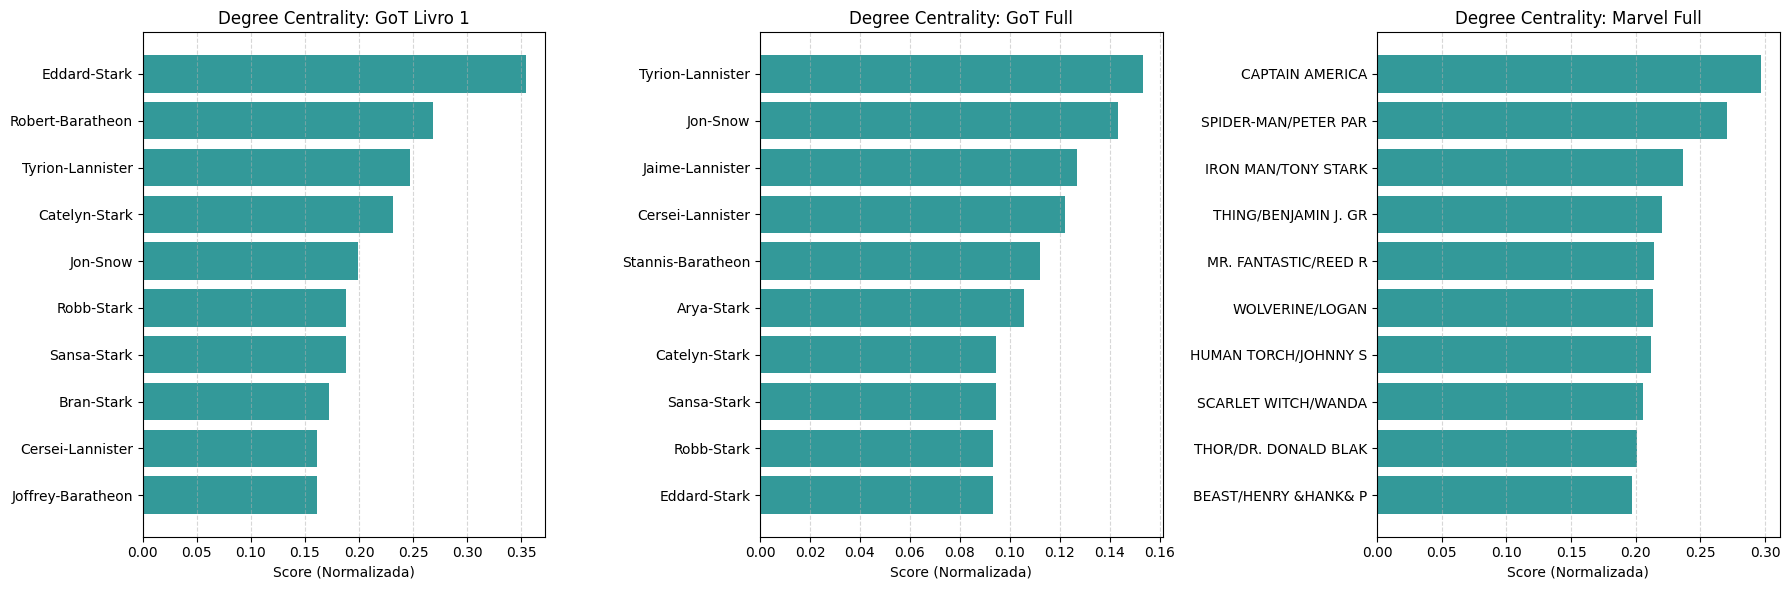

In [11]:
def test_degree_centrality(analyzers_dict):
    fig, axes = plt.subplots(1, len(analyzers_dict), figsize=(18, 6))
    
    if len(analyzers_dict) == 1:
        axes = [axes]

    for idx, (label, analyzer) in enumerate(analyzers_dict.items()):
        # 1. Calcular as scores (já devem vir normalizadas da classe)
        dc_scores = analyzer.degree_centrality()
        
        # 2. Ordenar e extrair Top 10
        top_10 = sorted(dc_scores.items(), key=lambda x: x[1], reverse=True)[:10]
        
        # 3. Preparar dados para o gráfico
        names = [x[0] for x in top_10]
        scores = [x[1] for x in top_10]
        
        # 4. Criar gráfico de barras horizontal
        axes[idx].barh(names[::-1], scores[::-1], color='teal', alpha=0.8)
        axes[idx].set_title(f"Degree Centrality: {label}")
        axes[idx].set_xlabel("Score (Normalizada)")
        axes[idx].grid(axis='x', linestyle='--', alpha=0.5)

        # Print dos resultados no terminal
        print(f"--- Top 10 Degree Centrality: {label} ---")
        for i, (name, score) in enumerate(top_10, 1):
            print(f"{i}. {name:<20} | {score:.4f}")
        print("\n")

    plt.tight_layout()
    plt.show()

# --- Execução do Teste ---
# Definimos os analisadores que queremos comparar
to_test = {
    "GoT Livro 1": CentralityAnalyzer(g1),
    "GoT Full": CentralityAnalyzer(g2),
    "Marvel Full": CentralityAnalyzer(g4)
}

test_degree_centrality(to_test)

## 3.2. Closeness Centrality (CC)
Utilizamos a fórmula de Wasserman_Faust, pois é a mais adequada para lidar com grafos que possam ter múltiplas componentes conexas.

A pontuação de um nó é baseada na soma das distâncias mais curtas entre ele e todos os outros nós. Quanto menor a soma das distâncias, mais central é o nó. A fórmula normalizada (para grafos conexos) é:

$$C_C(v) = \frac{n - 1}{\sum_{u \neq v} d(v, u)}$$

Onde:
* $d(v, u)$ é a distância do caminho mais curto entre os nós $v$ e $u$.
* $n - 1$ é o número de nós que podem ser alcançados.

Para redes com várias componentes (como os nossos CSVs), utilizamos frequentemente a variante de **Wasserman & Faust**, que ajusta o cálculo multiplicando a score pela fração de nós alcançáveis.

* **Significado:** Indica a rapidez com que a informação se espalha a partir de um nó para o resto da rede.
* **Contexto Social:** Personagens com alta Closeness Centrality são "hubs de informação". Mesmo que não tenham o maior número de amigos (Grau), estão a poucos "passos" de qualquer pessoa no reino. São os indivíduos melhor posicionados para monitorizar o que se passa em toda a rede.

A calcular Closeness para GoT Livro 1... (isto pode demorar uns segundos)
--- Top 10 Closeness: GoT Livro 1 ---
1. Eddard-Stark         | 0.5636
2. Robert-Baratheon     | 0.5455
3. Tyrion-Lannister     | 0.5110
4. Catelyn-Stark        | 0.5054
5. Robb-Stark           | 0.4973
6. Jon-Snow             | 0.4934
7. Sansa-Stark          | 0.4895
8. Bran-Stark           | 0.4869
9. Cersei-Lannister     | 0.4844
10. Joffrey-Baratheon    | 0.4806


A calcular Closeness para Marvel Small... (isto pode demorar uns segundos)
--- Top 10 Closeness: Marvel Small ---
1. Captain America      | 0.8274
2. Wolverine / Logan    | 0.7546
3. Spider-man / Peter Parker | 0.7512
4. Thing / Benjamin J. Gr | 0.7443
5. Vision               | 0.7426
6. Thor / Dr. Donald Blak | 0.7293
7. Beast / Henry &hank& P | 0.7293
8. Iron Man / Tony Stark | 0.7261
9. Mr. Fantastic / Reed R | 0.7181
10. Cyclops / Scott Summer | 0.7165




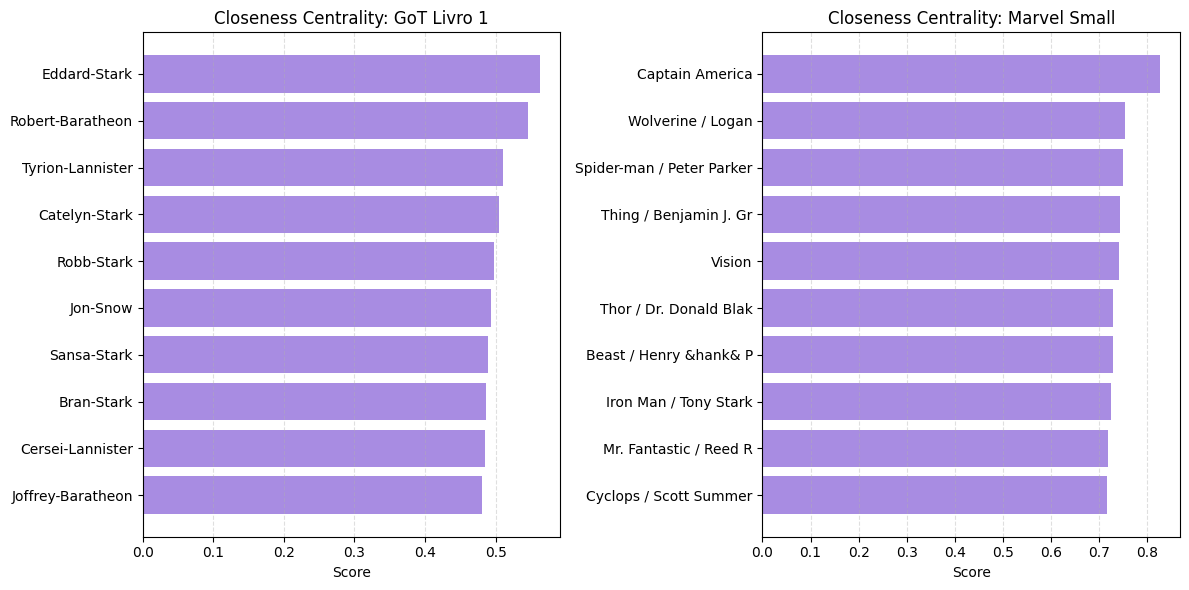

In [12]:
def test_closeness_centrality(analyzers_dict):
    # Criar a figura com subplots para cada analisador
    num_plots = len(analyzers_dict)
    fig, axes = plt.subplots(1, num_plots, figsize=(6 * num_plots, 6))
    
    if num_plots == 1:
        axes = [axes]

    for idx, (label, analyzer) in enumerate(analyzers_dict.items()):
        print(f"A calcular Closeness para {label}... (isto pode demorar uns segundos)")
        
        # 1. Calcular Closeness Scores
        cc_scores = analyzer.closeness_centrality()
        
        # 2. Ordenar e extrair Top 10
        top_10 = sorted(cc_scores.items(), key=lambda x: x[1], reverse=True)[:10]
        
        # 3. Preparar dados para o gráfico
        names = [x[0] for x in top_10]
        scores = [x[1] for x in top_10]
        
        # 4. Criar gráfico de barras horizontal
        axes[idx].barh(names[::-1], scores[::-1], color='mediumpurple', alpha=0.8)
        axes[idx].set_title(f"Closeness Centrality: {label}")
        axes[idx].set_xlabel("Score")
        axes[idx].grid(axis='x', linestyle='--', alpha=0.4)

        # Print dos resultados
        print(f"--- Top 10 Closeness: {label} ---")
        for i, (name, score) in enumerate(top_10, 1):
            print(f"{i}. {name:<20} | {score:.4f}")
        print("\n")

    plt.tight_layout()
    plt.show()

# --- Execução do Teste ---
# Nota: g3 (Marvel Small) e g1 (GoT Book 1) são mais rápidos para testar inicialmente
to_test = {
    "GoT Livro 1": CentralityAnalyzer(g1),
    "Marvel Small": CentralityAnalyzer(g3)
}

test_closeness_centrality(to_test)

## 3.3. Eigenvector Centrality (EC)
A *Eigenvector Centrality* é calculada utilizando o método iterativo de *Power Iteration*.

A **Eigenvector Centrality** é uma medida de influência que vai além da contagem direta de vizinhos. O princípio fundamental é: **a importância de um nó é determinada pela importância dos seus vizinhos.**

Ter 100 ligações com pessoas comuns pode ser menos valioso do que ter apenas 10 ligações com pessoas extremamente influentes. Esta métrica atribui scores relativos a todos os nós da rede baseando-se na ideia de que ligações provenientes de nós com scores altos contribuem mais para o score do nó em questão.

Como a importância de um nó depende dos seus vizinhos, e a dos vizinhos depende do nó, usamos um processo iterativo:
1.  Começamos com todos os nós tendo a mesma importância ($1/n$).
2.  Em cada iteração, atualizamos o score de cada nó somando os scores dos seus vizinhos.
3.  Normalizamos os resultados para evitar que os números cresçam infinitamente.
4.  Repetimos até os valores estabilizarem (convergência).

* **Significado:** Mede a influência global e o "prestígio" na rede.
* **Contexto Social:** É o equivalente a ser um "amigo de celebridades". Alguém com poucas ligações pode ter uma Eigenvector Centrality altíssima se estiver ligado diretamente aos principais líderes da rede.
* **Exemplo:** O algoritmo **PageRank** da Google é uma variante famosa desta métrica, onde a relevância de uma página web depende da relevância das páginas que apontam para ela.

A calcular Eigenvector para GoT Full...
--- Top 10 Eigenvector: GoT Full (Iterações: 26) ---
1. Tyrion-Lannister     | 0.2516
2. Cersei-Lannister     | 0.2358
3. Jaime-Lannister      | 0.2263
4. Joffrey-Baratheon    | 0.2144
5. Sansa-Stark          | 0.2058
6. Robert-Baratheon     | 0.1944
7. Eddard-Stark         | 0.1917
8. Stannis-Baratheon    | 0.1821
9. Catelyn-Stark        | 0.1759
10. Robb-Stark           | 0.1732


A calcular Eigenvector para Marvel Full...
--- Top 10 Eigenvector: Marvel Full (Iterações: 19) ---
1. CAPTAIN AMERICA      | 0.1167
2. IRON MAN/TONY STARK  | 0.1025
3. THING/BENJAMIN J. GR | 0.1009
4. SCARLET WITCH/WANDA  | 0.1007
5. SPIDER-MAN/PETER PAR | 0.1003
6. MR. FANTASTIC/REED R | 0.0997
7. HUMAN TORCH/JOHNNY S | 0.0986
8. VISION               | 0.0984
9. WOLVERINE/LOGAN      | 0.0983
10. BEAST/HENRY &HANK& P | 0.0955




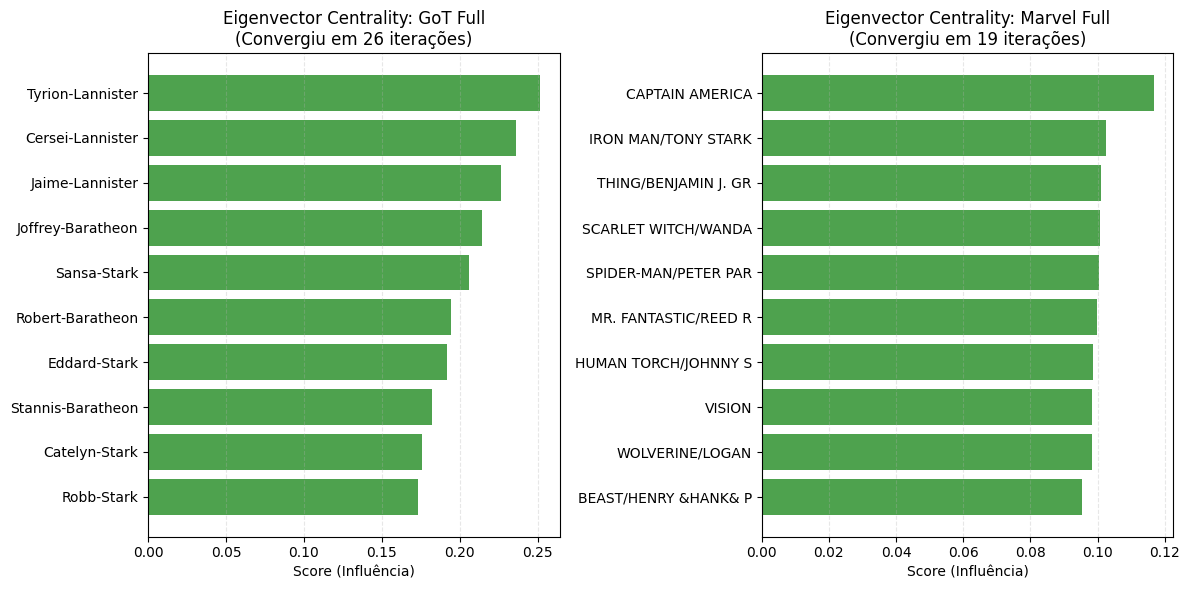

In [13]:
def test_eigenvector_centrality(analyzers_dict):
    num_plots = len(analyzers_dict)
    fig, axes = plt.subplots(1, num_plots, figsize=(6 * num_plots, 6))
    
    if num_plots == 1:
        axes = [axes]

    for idx, (label, analyzer) in enumerate(analyzers_dict.items()):
        print(f"A calcular Eigenvector para {label}...")
        
        # 1. Calcular Eigenvector Scores e o número de iterações até convergir
        scores, iterations = analyzer.eigenvector_centrality()
        
        # 2. Ordenar e extrais Top 10
        top_10 = sorted(scores.items(), key=lambda x: x[1], reverse=True)[:10]
        
        # 3. Preparar dados para o gráfico
        names = [x[0] for x in top_10]
        values = [x[1] for x in top_10]
        
        # 4. Criar gráfico
        axes[idx].barh(names[::-1], values[::-1], color='forestgreen', alpha=0.8)
        axes[idx].set_title(f"Eigenvector Centrality: {label}\n(Convergiu em {iterations} iterações)")
        axes[idx].set_xlabel("Score (Influência)")
        axes[idx].grid(axis='x', linestyle='--', alpha=0.3)

        # Print dos resultados
        print(f"--- Top 10 Eigenvector: {label} (Iterações: {iterations}) ---")
        for i, (name, score) in enumerate(top_10, 1):
            print(f"{i}. {name:<20} | {score:.4f}")
        print("\n")

    plt.tight_layout()
    plt.show()

# --- Execução do Teste ---
to_test = {
    "GoT Full": CentralityAnalyzer(g2),
    "Marvel Full": CentralityAnalyzer(g4)
}

test_eigenvector_centrality(to_test)

## 3.4. Betweenness Centrality (BC)
A *Betweenness Centrality* mede o poder de intermediação de um vértice usando o algoritmo otimizado de Brandes.

Imagine que quer enviar uma mensagem de uma personagem A para uma personagem B usando o menor número de pessoas possível. Se a personagem C estiver "no caminho" de quase todas as mensagens enviadas na rede, ela terá uma Betweenness Centrality muito elevada.

A fórmula para um nó $v$ é:
$$C_B(v) = \sum_{s \neq v \neq t} \frac{\sigma_{st}(v)}{\sigma_{st}}$$

Onde:
* $\sigma_{st}$ é o número total de caminhos mais curtos entre o nó $s$ e o nó $t$.
* $\sigma_{st}(v)$ é o número desses caminhos que passam pelo nó $v$.

* **Significado:** Representa o controlo sobre o fluxo de informação. Um nó com alta intermediação pode atuar como um "pedágio" ou um "filtro".
* **Contexto Social:** Personagens com alta Betweenness são as que ligam diferentes comunidades ou núcleos narrativos que, de outra forma, estariam isolados. Se esta personagem for removida, a rede corre o risco de se desmoronar em várias partes separadas.
* **Exemplo:** Em Game of Thrones, personagens que viajam entre diferentes regiões (como Arya Stark ou Tyrion) ou que fazem política entre várias famílias (como Varys ou Littlefinger) tendem a ter scores altíssimos nesta métrica.

A calcular Betweenness para GoT Livro 1... (pode demorar)
--- Top 10 Betweenness: GoT Livro 1 ---
1. Eddard-Stark         | 4638.5350
2. Robert-Baratheon     | 3682.3910
3. Tyrion-Lannister     | 3272.6060
4. Jon-Snow             | 2952.0573
5. Catelyn-Stark        | 2604.7556
6. Daenerys-Targaryen   | 1484.2780
7. Robb-Stark           | 1255.6897
8. Drogo                | 1115.0946
9. Bran-Stark           | 960.0319
10. Sansa-Stark          | 639.0769


A calcular Betweenness para Marvel Small... (pode demorar)
--- Top 10 Betweenness: Marvel Small ---
1. Captain America      | 3555.9020
2. Spider-man / Peter Parker | 3274.3282
3. Wolverine / Logan    | 1879.9284
4. Beast / Henry &hank& P | 1652.9813
5. Thor / Dr. Donald Blak | 1517.6061
6. Vision               | 1516.3724
7. Thing / Benjamin J. Gr | 1326.3106
8. Iron Man / Tony Stark | 1318.7285
9. Cyclops / Scott Summer | 1183.8623
10. Mr. Fantastic / Reed R | 1116.2935




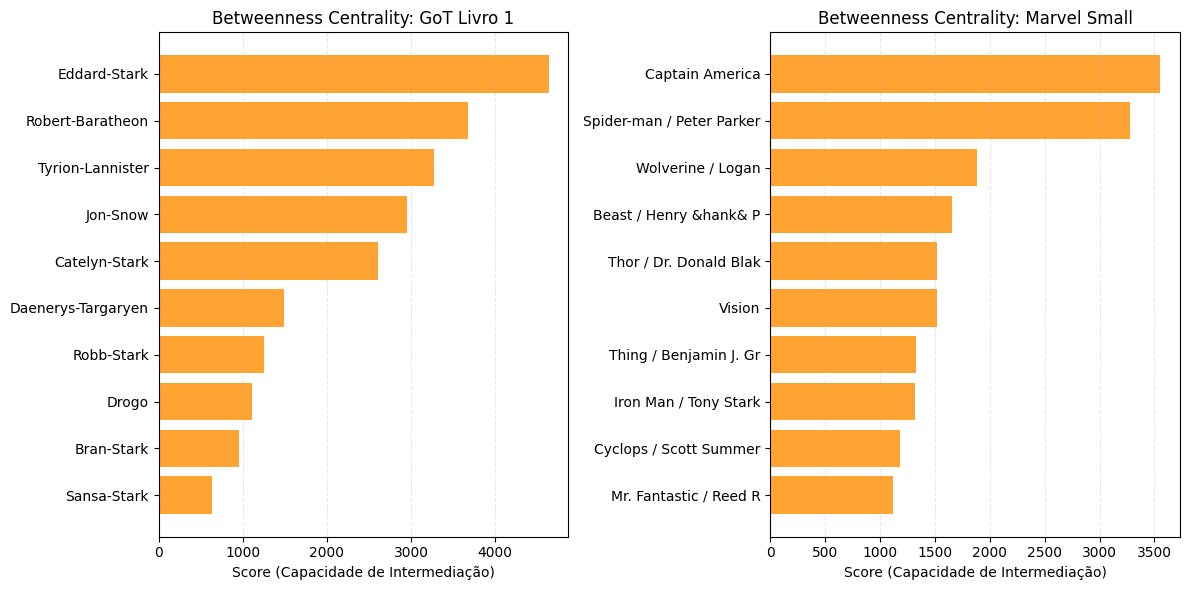

In [14]:
def test_betweenness_centrality(analyzers_dict):
    num_plots = len(analyzers_dict)
    fig, axes = plt.subplots(1, num_plots, figsize=(6 * num_plots, 6))
    
    if num_plots == 1:
        axes = [axes]

    for idx, (label, analyzer) in enumerate(analyzers_dict.items()):
        print(f"A calcular Betweenness para {label}... (pode demorar)")
        
        # 1. Calcular Betweenness Scores
        bc_scores = analyzer.betweenness_centrality()
        
        # 2. Ordenar e extrair Top 10
        top_10 = sorted(bc_scores.items(), key=lambda x: x[1], reverse=True)[:10]
        
        # 3. Preparar dados para o gráfico
        names = [x[0] for x in top_10]
        values = [x[1] for x in top_10]
        
        # 4. Criar gráfico
        axes[idx].barh(names[::-1], values[::-1], color='darkorange', alpha=0.8)
        axes[idx].set_title(f"Betweenness Centrality: {label}")
        axes[idx].set_xlabel("Score (Capacidade de Intermediação)")
        axes[idx].grid(axis='x', linestyle='--', alpha=0.3)

        # Print dos resultados
        print(f"--- Top 10 Betweenness: {label} ---")
        for i, (name, score) in enumerate(top_10, 1):
            print(f"{i}. {name:<20} | {score:.4f}")
        print("\n")

    plt.tight_layout()
    plt.show()

# --- Execução do Teste ---
# Recomendo testar com os ficheiros menores primeiro para ver o resultado rápido
to_test = {
    "GoT Livro 1": CentralityAnalyzer(g1),
    "Marvel Small": CentralityAnalyzer(g3)
}

test_betweenness_centrality(to_test)

# 4. Análise Empírica do tempo de execução

## 4.1. Escalabilidade dos Algoritmos

* ### 4.1.1. Medir o Tempo

In [15]:
def medir_tempo(func, *args, repeticoes=5):
    tempos = []
    for _ in range(repeticoes):
        inicio = time.time()
        func(*args)
        fim = time.time()
        tempos.append(fim - inicio)
    return statistics.median(tempos)

* ### 4.1.2. Carregar Data Sets

In [16]:
datasets = {
    "got_book1": "got_book1.csv",
    "got_full": "got_full.csv",
    "marvel_small": "marvel_small.csv",
    "marvel_full": "marvel_full.csv"
}

* ### 4.1.3. Executar medições

In [19]:
resultados = {
    "dataset": [],
    "n": [],
    "m": [],
    "n+m": [],
    "DC": [],
    "CC": [],
    "EC": [],
    "BC": [],
    "k": []  # número de iterações do EC
}

for nome, path in datasets.items():
    print(f"\nProcessando {nome}...")
    
    g = load_graph_from_file(path)
    analyzer = CentralityAnalyzer(g)
    
    n = g.order()
    m = g.size()
    
    repeticoes = 5 if nome != "marvel_full" else 1
    
    t_dc = medir_tempo(analyzer.degree_centrality, repeticoes=repeticoes)
    t_cc = medir_tempo(analyzer.closeness_centrality, repeticoes=repeticoes)
    
    # EC devolve (scores, k)
    def run_ec():
        return analyzer.eigenvector_centrality()
    
    tempos_ec = []
    ks = []
    for _ in range(repeticoes):
        inicio = time.time()
        _, k = run_ec()
        fim = time.time()
        tempos_ec.append(fim - inicio)
        ks.append(k)
    
    t_ec = statistics.median(tempos_ec)
    k_medio = int(statistics.median(ks))
    
    t_bc = medir_tempo(analyzer.betweenness_centrality, repeticoes=repeticoes)
    
    resultados["dataset"].append(nome)
    resultados["n"].append(n)
    resultados["m"].append(m)
    resultados["n+m"].append(n + m)
    resultados["DC"].append(t_dc)
    resultados["CC"].append(t_cc)
    resultados["EC"].append(t_ec)
    resultados["BC"].append(t_bc)
    resultados["k"].append(k_medio)



Processando got_book1...

Processando got_full...

Processando marvel_small...

Processando marvel_full...


# 4.4. Gráfico log-log

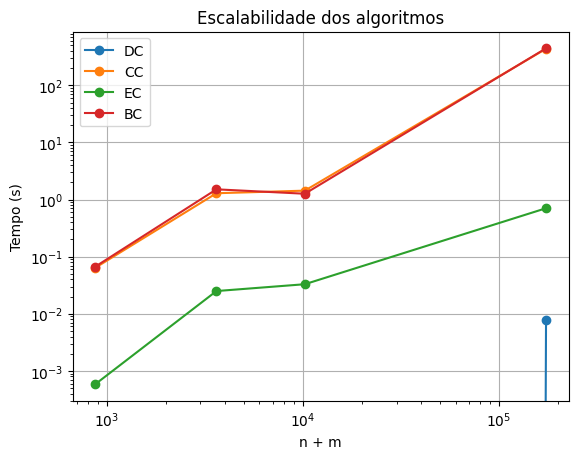

In [20]:
x = resultados["n+m"]

plt.figure()
plt.xscale("log")
plt.yscale("log")

plt.plot(x, resultados["DC"], marker='o', label="DC")
plt.plot(x, resultados["CC"], marker='o', label="CC")
plt.plot(x, resultados["EC"], marker='o', label="EC")
plt.plot(x, resultados["BC"], marker='o', label="BC")

plt.xlabel("n + m")
plt.ylabel("Tempo (s)")
plt.title("Escalabilidade dos algoritmos")
plt.legend()
plt.grid()
plt.show()

# 4.2. Gráfico TBC / TCC

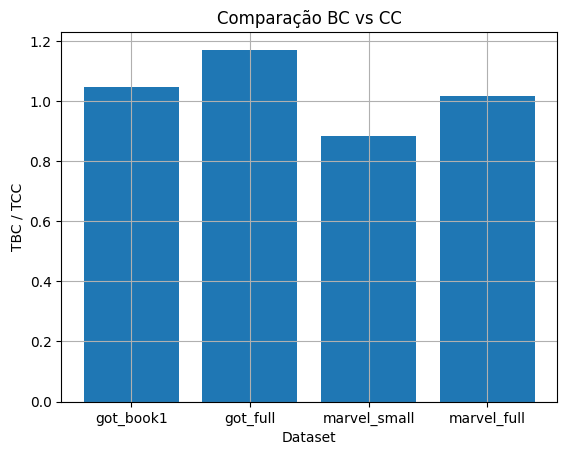

In [21]:
razoes_bc_cc = [bc/cc for bc, cc in zip(resultados["BC"], resultados["CC"])]

plt.figure()
plt.bar(resultados["dataset"], razoes_bc_cc)
plt.xlabel("Dataset")
plt.ylabel("TBC / TCC")
plt.title("Comparação BC vs CC")
plt.grid()
plt.show()

## 4.3 Gráfico TCC/TEC vs n/k